# TF-IDF Lyric-Based Song Recommender

**Data**: Personal Spotify liked songs (~1928 songs with lyrics fetched via Genius API)

## 1. Imports & Setup

In [1]:
import sys
sys.path.append('../src')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

from tfidf_recommender import build_tfidf_recommender, recommend_songs

pd.set_option('display.max_colwidth', 60)

## 2. Load Data & Build Recommender

In [2]:
LYRICS_PATH = '../data/processed/lyrics_clean.csv'

lyrics_df, tfidf_matrix, similarity_matrix = build_tfidf_recommender(LYRICS_PATH)

print(f'Songs loaded:       {len(lyrics_df)}')
print(f'TF-IDF matrix:      {tfidf_matrix.shape}  (songs x vocab terms)')
print(f'Similarity matrix:  {similarity_matrix.shape}')
lyrics_df.head()

Songs loaded:       1688
TF-IDF matrix:      (1688, 10000)  (songs x vocab terms)
Similarity matrix:  (1688, 1688)


,track_id,track_name,artist,lyrics,processed_lyrics
0,0qNnE0beu4OfHk8Txa3vGt,Soul Flower - Remix,The Pharcyde,"[Chorus]\nEe, ah, ooh, ah, ah, ee, ah, ooh, ah, ah\nEe, ...",ee ah ooh ah ah ee ah ooh ah ah ee ah ooh ah ah ee ah oo...
1,7AHX0F99w4x23uSZihklZ6,My God,Tapir!,[Verse 1]\nWaking up with intuition\nGoing back to sleep...,waking intuition going sleep rumination premonition youl...
2,1KbpVvPiLAt1Wsh5gr2YKM,Take a Trip,TV Girl,"[Intro]\nTake, take, take a trip, take a trip back down\...",trip trip memory lane trip trip memory lane hand pocket ...
3,56s4IHGnJVGZYcdOVmC3eb,"I Love Life, Thank You",Mac Miller,"[Intro]\nAlright then, bitch\nHa, ya\nUh\nA million moth...",alright bitch ha ya uh million motherfuckin fan as biotc...
4,5XufqHphZkJhIkc5wlEST7,Soft Rock Band,Good Morning,[Intro]\nWell I played time in exile\nAnd the weather it...,played time exile weather hot dream recollection parking...


## 3. Vocabulary Exploration
Exploration of what the TF-IDF model captured in its vocabulary.

In [3]:
vectorizer = TfidfVectorizer(max_features=10000, ngram_range=(1, 2), min_df=2)
vectorizer.fit(lyrics_df['processed_lyrics'])

vocab = vectorizer.get_feature_names_out()
print(f'Vocabulary size: {len(vocab)} terms')
print(f'\nSample unigrams: {[t for t in vocab if " " not in t][:20]}')
print(f'\nSample bigrams:  {[t for t in vocab if " " in t][:20]}')

Vocabulary size: 10000 terms

Sample unigrams: ['10', '100', '11', '12', '13', '14', '15', '16', '19', '1984', '1995', '20', '200', '2015', '2020', '2023', '2030', '21', '21st', '22']

Sample bigrams:  ['21 savage', '21st century', 'aap rocky', 'act like', 'actin like', 'acting like', 'admit ive', 'advice hey', 'afraid im', 'african american', 'ah ah', 'ah baby', 'ah future', 'ah got', 'ah ha', 'ah know', 'ah let', 'ah oh', 'ah ooh', 'ah yeah']


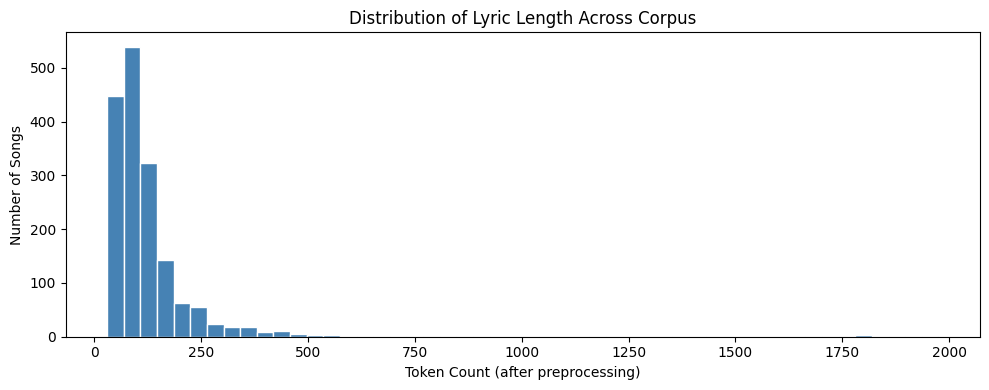

count    1688.0
mean      134.7
std       178.7
min        30.0
25%        67.0
50%        95.0
75%       138.0
max      1975.0
Name: token_count, dtype: float64


In [4]:
# Distribution of processed lyrics length
lyrics_df['token_count'] = lyrics_df['processed_lyrics'].apply(lambda x: len(str(x).split()))

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(lyrics_df['token_count'], bins=50, color='steelblue', edgecolor='white')
ax.set_xlabel('Token Count (after preprocessing)')
ax.set_ylabel('Number of Songs')
ax.set_title('Distribution of Lyric Length Across Corpus')
plt.tight_layout()
plt.show()

print(lyrics_df['token_count'].describe().round(1))

### Plot Function for Word Similarity

In [23]:
def plot_top_terms(seed_title, seed_artist=None, n_terms=20, ax=None):
    matches = lyrics_df[lyrics_df["track_name"].str.lower() == seed_title.lower()]
    if seed_artist:
        matches = matches[matches["artist"].str.lower() == seed_artist.lower()]
    
    if matches.empty:
        raise ValueError(f"No match found for {seed_title} by {seed_artist}")
    
    seed_idx = matches.index[0]
    
    vec = TfidfVectorizer(max_features=10000, ngram_range=(1,2), min_df=2)
    matrix = vec.fit_transform(lyrics_df["processed_lyrics"])
    feature_names = vec.get_feature_names_out()
    
    scores = matrix[seed_idx].toarray().flatten()
    top_indices = scores.argsort()[::-1][:n_terms]
    
    top_terms = [feature_names[i] for i in top_indices]
    top_scores = [scores[i] for i in top_indices]
    
    if ax is None:
        fig, ax = plt.subplots(figsize=(10, 5))
    
    ax.barh(top_terms[::-1], top_scores[::-1], color='steelblue')
    ax.set_xlabel("TF-IDF Score")
    ax.set_title(f"Top {n_terms} Terms:\n'{seed_title}'")

## 4. Generate Recommendations
Testing recommender with a few seed songs, trying different songs to see how the system behaves across contents. 

In [5]:
def show_recommendations(seed_title, seed_artist=None, k=10):
    """Wrapper that prints recommendations in a readable format."""
    recs = recommend_songs(
        lyrics_df, similarity_matrix,
        seed_title=seed_title,
        seed_artist=seed_artist,
        k=k
    )
    print(f"\nSeed: '{seed_title}'{' by ' + seed_artist if seed_artist else ''}")
    print('-' * 55)
    print(recs.to_string(index=True))
    return recs

In [21]:
# --- Test 1 from the 90s Grunge Era:
recs_1 = show_recommendations('Iron Clad Lou', seed_artist='Hum', k=10)


Seed: 'Iron Clad Lou' by Hum
-------------------------------------------------------
                   track_name                        artist  similarity
0            Stand up and Win                        Spymob    0.150625
1                Never Lonely                Space Mountain    0.141657
2                    Downtown                       Varsity    0.127298
3                        Rain  World's Experience Orchestra    0.123007
4                Faxing It In                       Smushie    0.115240
5                     Hippies                      flipturn    0.112796
6                       Alive                     Pearl Jam    0.108595
7                        2023               Blue Rain Boots    0.108516
8  Warmest Part of the Winter                       Voxtrot    0.105749
9               Down the Line                 Beach Fossils    0.094675


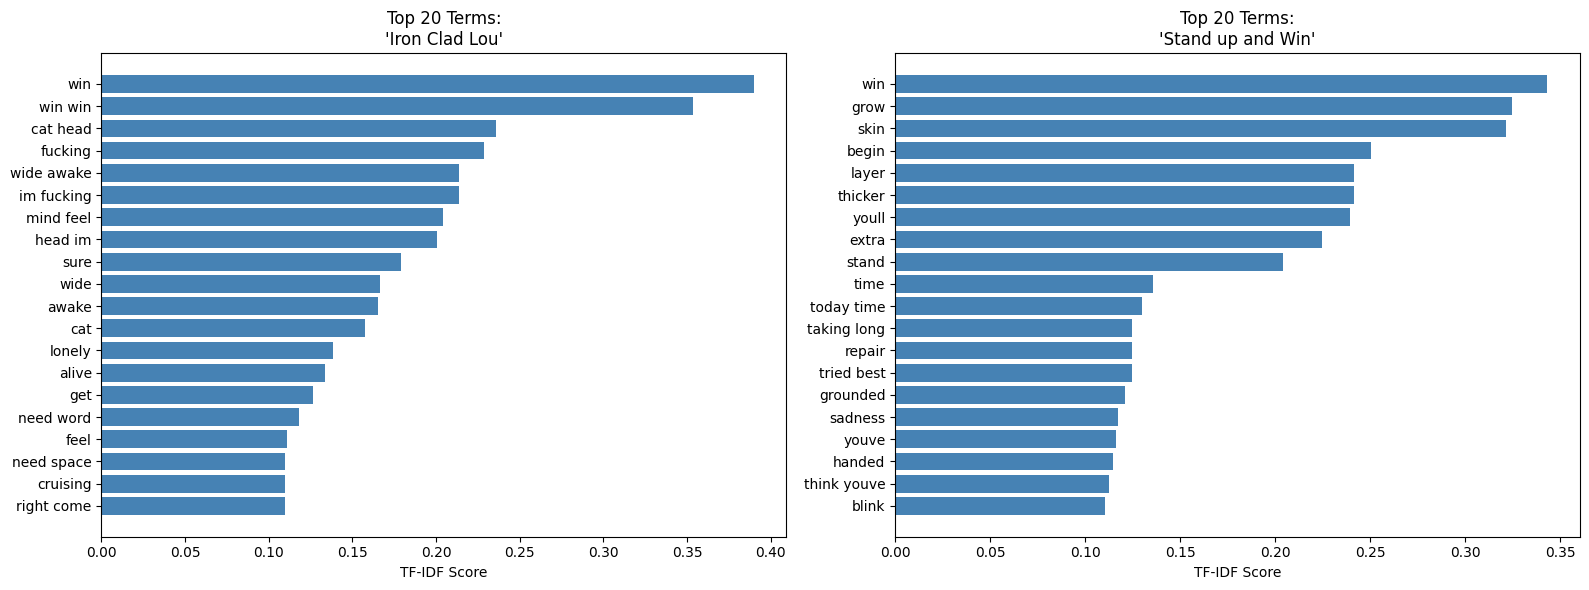

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

plot_top_terms('Iron Clad Lou', seed_artist='Hum', ax=axes[0])
plot_top_terms('Stand up and Win', seed_artist='Spymob', ax=axes[1])

plt.tight_layout()
plt.show()

In [15]:
# --- Test 2: 70s Soul
recs_2 = show_recommendations('Can I Help You?', seed_artist="Amnesty", k=10)


Seed: 'Can I Help You?' by Amnesty
-------------------------------------------------------
                              track_name                artist  similarity
0  Sweetest Thing on This Side of Heaven  Papa Bear & His Cubs    0.302154
1                                Chicago       Michael Jackson    0.165856
2                                 Bailee             The Licks    0.159727
3                      Wizard Of Finance            Parliament    0.142556
4                           Cause = Time   Broken Social Scene    0.140919
5                           Mystery Girl             Housecall    0.118191
6                                  Ellie          Make Friends    0.116658
7                         Hard To Handle      The Black Crowes    0.095303
8                  Hey, Who Really Cares         Linda Perhacs    0.093435
9                    Touched by an Angel          The Memories    0.088910


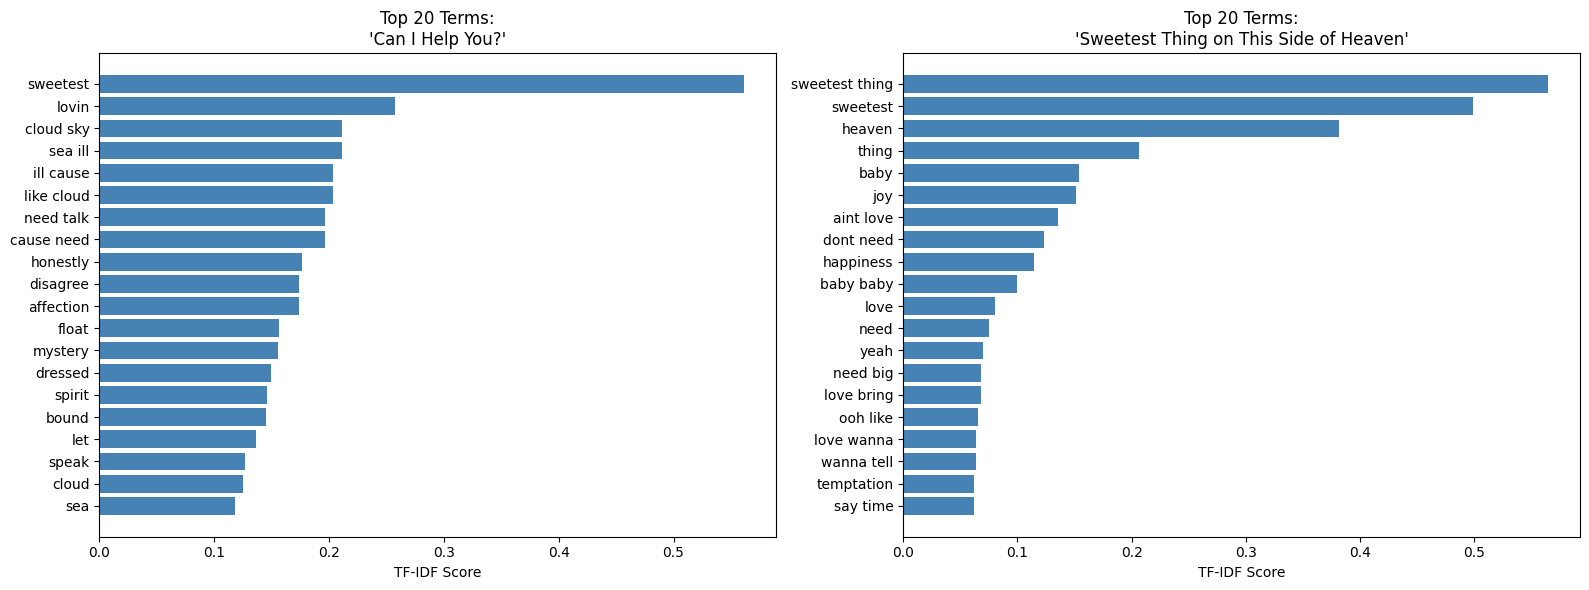

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

plot_top_terms('Can I Help You?', seed_artist="Amnesty", ax=axes[0])
plot_top_terms('Sweetest Thing on This Side of Heaven', seed_artist="Papa Bear & His Cubs", ax=axes[1])

plt.tight_layout()
plt.show()

In [18]:
# --- Test 3: Latin Music
recs_3 = show_recommendations("Los Libros de la Buena Memoria", seed_artist="Invisible")


Seed: 'Los Libros de la Buena Memoria' by Invisible
-------------------------------------------------------
                                                    track_name                       artist  similarity
0                                                My Conception                    Ryo Fukui    0.654586
1                      SMUCKERS (feat. Lil Wayne & Kanye West)           Tyler, The Creator    0.494198
2                                    Las Habladurias del Mundo              Pescado Rabioso    0.461502
3  After The Storm (feat. Tyler, The Creator & Bootsy Collins)                   Kali Uchis    0.441737
4                                    Como Mata el Viento Norte  La Maquina De Hacer Pájaros    0.417646
5                                                 Oh Qué Será?                 Willie Colón    0.411497
6                                      Promesas Sobre El Bidet                Charly García    0.362218
7                                        ･－･･ ･ － ･･ － －－･ 

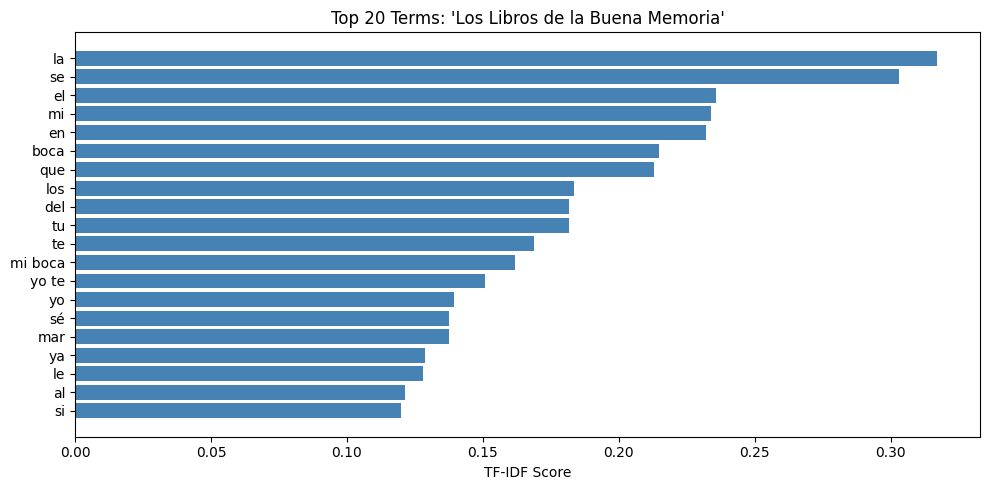

In [19]:
plot_top_terms("Los Libros de la Buena Memoria", seed_artist="Invisible")

In [ ]:
# --- Test 4: Curent Hip-Hop
recs_4 = show_recommendations('House Money', seed_artist="Baby Keem", k=10)


Seed: 'House Money' by Baby Keem
-------------------------------------------------------
                            track_name                      artist  similarity
0  Jesus Is The One (I Got Depression)                    Zack Fox    0.444534
1                 Can You Rap Like Me?                Trippie Redd    0.366565
2                          Hit Bout It                  Lil Yachty    0.332097
3                          Blood On Me                      Sampha    0.322671
4                           REEL IT IN                       Aminé    0.290434
5                        trademark usa                   Baby Keem    0.274843
6                             JayJay-Z                   Zelooperz    0.269611
7                 Fresh Prince Of Utah  YoungBoy Never Broke Again    0.268657
8                                CORSO          Tyler, The Creator    0.262410
9                             WILSHIRE          Tyler, The Creator    0.240059


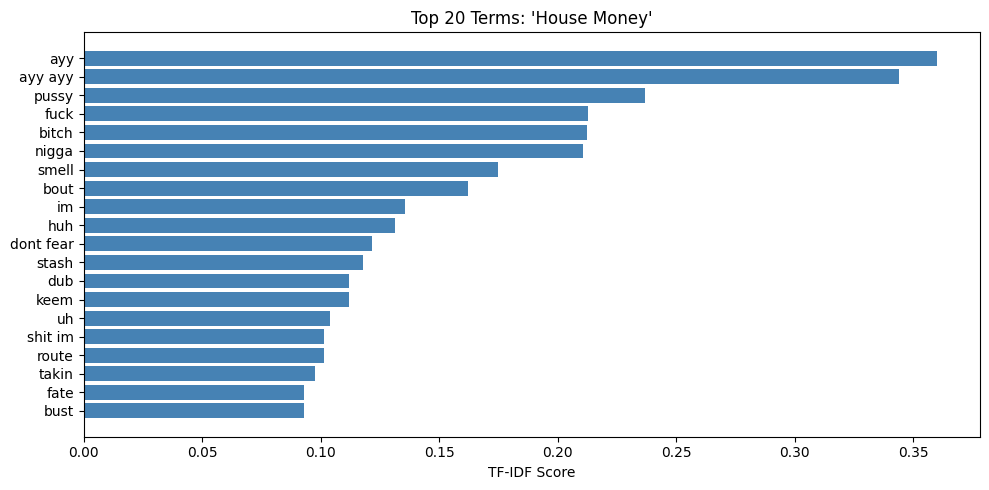

In [14]:
plot_top_terms('House Money', seed_artist="Baby Keem")

## 5. Similary Score Distribution
Looking at how similar songs generally are to each other in the corpus and whetehr the model is producing meanignufl seperation or mostly near-zero scores. 

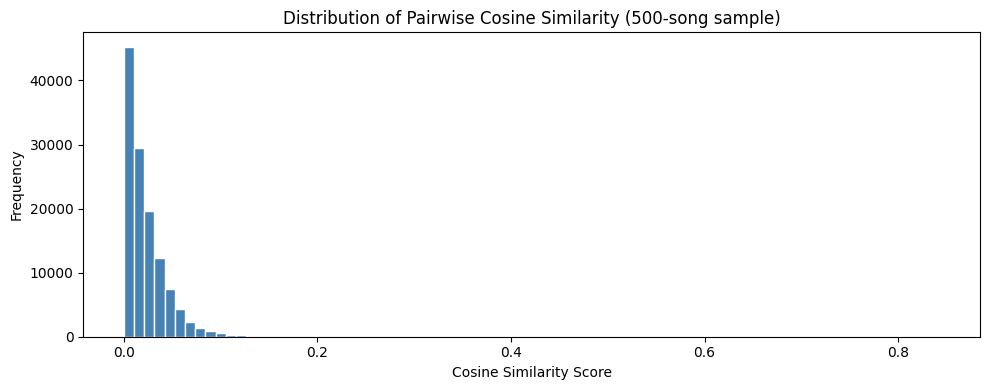

Mean similarity:   0.0225
Median similarity: 0.0162
Max similarity:    0.8425
% scores > 0.1:    1.2%


In [9]:
sample_size = 500
sample_indices = np.random.choice(len(lyrics_df), size=sample_size, replace=False)
sample_sim = similarity_matrix[np.ix_(sample_indices, sample_indices)]

# Extract upper triangle (exclude diagonal self-similarity)
upper = sample_sim[np.triu_indices(sample_size, k=1)]

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(upper, bins=80, color='steelblue', edgecolor='white')
ax.set_xlabel('Cosine Similarity Score')
ax.set_ylabel('Frequency')
ax.set_title('Distribution of Pairwise Cosine Similarity (500-song sample)')
plt.tight_layout()
plt.show()

print(f'Mean similarity:   {upper.mean():.4f}')
print(f'Median similarity: {np.median(upper):.4f}')
print(f'Max similarity:    {upper.max():.4f}')
print(f'% scores > 0.1:    {(upper > 0.1).mean() * 100:.1f}%')

## 6. Most Similar Pairs in the Corpus

In [10]:
sim_copy = similarity_matrix.copy()
np.fill_diagonal(sim_copy, 0)  # zero out diagonal

top_flat = np.argsort(sim_copy.ravel())[::-1][:30]
top_pairs = np.unravel_index(top_flat, sim_copy.shape)

seen = set()
rows = []
for i, j in zip(*top_pairs):
    pair_key = tuple(sorted((i, j)))
    if pair_key in seen:
        continue
    seen.add(pair_key)
    rows.append({
        'Song A': f"{lyrics_df.loc[i, 'track_name']} — {lyrics_df.loc[i, 'artist']}",
        'Song B': f"{lyrics_df.loc[j, 'track_name']} — {lyrics_df.loc[j, 'artist']}",
        'Similarity': round(sim_copy[i, j], 4)
    })
    if len(rows) == 15:
        break

pd.DataFrame(rows)

,Song A,Song B,Similarity
0,"Prune, You Talk Funny — Gus Dapperton",Undoer — Geese,0.9513
1,New Humanity — Los Retros,Lemon To My Lime — The Grogans,0.9360
2,Come for Me — Twin Peaks,New Humanity — Los Retros,0.9226
3,Lemon To My Lime — The Grogans,Come for Me — Twin Peaks,0.9076
4,Love the One You're With — The Isley Brothers,ramadan — ee,0.9029
5,Strawberry Letter 23 — The Brothers Johnson,Strawberry Letter 23 — Shuggie Otis,0.8990
6,Let Your Heart Hold Fast — Fort Atlantic,Cold Cold Man — Saint Motel,0.8910
7,"For the Love of You, Pts. 1 & 2 — The Isley Brothers",Outer Space — Liz Cooper,0.8570
8,Bad Habit — Steve Lacy,I Have a Woman Inside My Soul — Yoko Ono,0.8474
9,"Besties — Black Country, New Road",Sleep Talking — Indigo De Souza,0.8454


## Results
Overall, I think the simplicity of a TF-IDF model is highlighted here in these tests, but so is the task at hand. 

**Test 1: Grunge Music**
The TF-IDF model performed terribly on this test. It's highest similarity was 0.1506, primarily due to the recurring use of the word "win." In addition, only one of the top-10 most similar songs was actually considered grunge: Alive, by Pearl Jam. Yet, it was ranked as the 6th most similar. However, this tells us a lot about the genre. Grunge is the fusion of punk rock and heavy metal, charaterized by heavy guitar riffs, dark baselines, and the angst in which artists sang. The word frequency plot for this test's seed song show some of that lyrical angst, but the tone it is conveyed in proves to be is defining feature. 

**Test 2: Soul Music**
The TF-IDF model in its second test performed better, but still not well. It's highest ranked similarity was also a soul song, following similar themes around love, sweetness, and the need to express these feelings. However, similarites quickly dropped after rank one and only one other soul song was identified in the top-10. This was a more suprising result than the first test. Grunge music clearly relies on its hardcore rock vibes, and while soul music has its own music ecosystem too, I expected to see more simialrity present in the genre surrounding the genres lexicon. 

**Test 3: Latin Test**
This is was the TF-IDF model's most interesting results. First, we see a lot of high scoring Spanish langugae matches that are all Argentine progressive rock bands from the same era as Invisible. The model is picking up shared Spanish vocabulary. 

# LATENT SENMANTIC ANALYSIS via SVD